# Week 3 — Implement Drift Scenarios
## UNSW-NB15 · Controlled Drift Generation & Degradation Measurement

In [6]:
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)

# ----- Load raw test set -----
test_raw = pd.read_csv('data/UNSW_NB15_testing-set/UNSW_NB15_testing-set.csv')
print(f'Raw test set shape: {test_raw.shape}')

# ----- Load trained models and scaler -----
lr_model  = joblib.load('data/logistic_regression_baseline.pkl')
rf_model  = joblib.load('data/Random_Forest_baseline.pkl')
xgb_model = joblib.load('data/XGBoost_baseline.pkl')
scaler    = joblib.load('data/scaler.pkl')

models = {
    'Logistic Regression': lr_model,
    'Random Forest': rf_model,
    'XGBoost': xgb_model
}

print(f'Models loaded: {list(models.keys())}')
print('Scaler loaded')

Raw test set shape: (175341, 45)
Models loaded: ['Logistic Regression', 'Random Forest', 'XGBoost']
Scaler loaded



**Drift types:**
1. **Feature noise** — Gaussian noise added to numeric features
2. **Missingness** — Random masking of values (sensor degradation)
3. **Class prior shift** — Change in attack/benign proportions

**Severity levels:** Low, Medium, High

---
### 1. Preprocessing — Clean Test Set (Reference Baseline)

We reproduce the exact same preprocessing pipeline from Week 1.

In [7]:
DROP_COLS = ['id', 'attack_cat']
TARGET = 'label'

def preprocess(df):
    """Same preprocessing as Week 1."""
    df = df.copy()
    df.drop(columns=[c for c in DROP_COLS if c in df.columns], inplace=True)
    for col in df.select_dtypes(include='object').columns:
        if col != TARGET:
            df[col] = LabelEncoder().fit_transform(df[col].astype(str))
    return df

test_clean = preprocess(test_raw)
X_test_clean = test_clean.drop(columns=[TARGET])
y_test_clean = test_clean[TARGET]

# Scaled version for Logistic Regression
X_test_sc = scaler.transform(X_test_clean)

# Store feature names and numeric columns for drift functions
feature_names = X_test_clean.columns.tolist()
numeric_cols = X_test_clean.select_dtypes(include=[np.number]).columns.tolist()

print(f'Total features: {len(feature_names)}')
print(f'Numeric features: {len(numeric_cols)}')
print(f'Clean test set shape: {X_test_clean.shape}')
print(f'Target distribution: {y_test_clean.value_counts().to_dict()}')

Total features: 42
Numeric features: 42
Clean test set shape: (175341, 42)
Target distribution: {1: 119341, 0: 56000}


---
### 2. Evaluation Function

This function takes a (possibly drifted) test set and returns metrics for all 3 models.
Note: Logistic Regression requires scaled data; Random Forest and XGBoost do not.

In [ ]:
def evaluate_all_models(X_test_df, y_test, models, scaler):
    results = {}
    X_sc = scaler.transform(X_test_df)
    
    for name, model in models.items():
        X_input = X_sc if name == 'Logistic Regression' else X_test_df.values
        
        y_pred = model.predict(X_input)
        y_proba = model.predict_proba(X_input)[:, 1]
        
        results[name] = {
            'Accuracy':  round(accuracy_score(y_test, y_pred), 4),
            'Precision': round(precision_score(y_test, y_pred, zero_division=0), 4),
            'Recall':    round(recall_score(y_test, y_pred, zero_division=0), 4),
            'F1':        round(f1_score(y_test, y_pred, zero_division=0), 4),
            'ROC-AUC':   round(roc_auc_score(y_test, y_proba), 4)
        }
    
    return results

# ----- Clean baseline -----
baseline_results = evaluate_all_models(X_test_clean, y_test_clean, models, scaler)
print('=== BASELINE (clean test set) ===')
print(pd.DataFrame(baseline_results).T.to_string())

=== BASELINE (clean test set) ===
                     Accuracy  Precision  Recall      F1  ROC-AUC
Logistic Regression    0.6501     0.9944  0.4887  0.6553   0.9687
Random Forest          0.9017     0.9879  0.8662  0.9231   0.9859
XGBoost                0.9128     0.9704  0.8993  0.9335   0.9826


---
### 3. Drift Type 1 — Feature Noise

#### What we do

For each numeric feature in the test set, we add random noise drawn from a
Gaussian (normal) distribution.

#### Why Gaussian noise?

In real networks, measurement errors come from many small independent sources:
clock imprecision, packet queuing delays, rounding errors, etc. The Central Limit
Theorem tells us that the sum of many small independent random effects follows a
Gaussian distribution. This makes it the standard model for measurement noise in
engineering and science.

A Gaussian $\mathcal{N}(\mu, \sigma^2)$ is defined by two parameters:
- $\mu = 0$: the noise has no systematic bias (equally likely to be positive or negative)
- $\sigma = \alpha \times \sigma_j$: the noise amplitude is proportional to the feature's
  natural variability $\sigma_j$


#### Signal-to-Noise Ratio (SNR)

$\text{SNR} = \text{Var}(\text{signal}) / \text{Var}(\text{noise}) = \sigma_j^2 / (\alpha^2 \sigma_j^2) = 1/\alpha^2$

| Severity | $\alpha$ | SNR   | Meaning                              |
|----------|---------|-------|--------------------------------------|
| Low      | 0.1     | 100   | Signal is 100x stronger than noise   |
| Medium   | 0.5     | 4     | Signal is 4x stronger                |
| High     | 1.0     | 1     | Noise is as strong as the signal     |

In [ ]:
def apply_noise_drift(X_df, severity, numeric_cols):
    noise_levels = {'low': 0.1, 'medium': 0.5, 'high': 1.0}
    alpha = noise_levels[severity]
    
    X_noisy = X_df.copy()
    for col in numeric_cols:
        col_std = X_df[col].std()
        if col_std > 0:
            noise = np.random.normal(0, alpha * col_std, size=len(X_df))
            X_noisy[col] = X_df[col] + noise
    
    return X_noisy

# Generate and evaluate all 3 severity levels
noise_results = {}
noise_datasets = {}

for severity in ['low', 'medium', 'high']:
    X_noisy = apply_noise_drift(X_test_clean, severity, numeric_cols)
    noise_datasets[severity] = X_noisy
    noise_results[severity] = evaluate_all_models(X_noisy, y_test_clean, models, scaler)
    
    rf_recall = noise_results[severity]['Random Forest']['Recall']
    rf_f1 = noise_results[severity]['Random Forest']['F1']
    print(f'Noise {severity:6s} -> RF Recall: {rf_recall:.4f}  F1: {rf_f1:.4f}')

print('\nFeature noise drift — done')

Noise low    -> RF Recall: 0.8958  F1: 0.9065
Noise medium -> RF Recall: 0.8331  F1: 0.8370
Noise high   -> RF Recall: 0.7895  F1: 0.7905

Feature noise drift — done


### 4. Drift Type 2 — Missingness (Sensor Degradation)

#### What we do

For each numeric value in the test set, we flip a coin: with probability $\beta$,
we replace the value with 0. The value is lost — the model sees a 0 where there
should have been meaningful data.

#### Why replace with 0 (and not NaN)?

Our models (RF, XGBoost, LR) cannot handle NaN values — they would crash.
In practice, when a sensor fails, the system often records a default value (0)
rather than explicitly marking the data as missing. This makes the corruption
harder to detect because 0 might look like a valid value.

#### Why is this harmful to the model?

Consider the feature `sttl` (source Time-To-Live), which is typically around 254
for normal traffic. If 50% of sttl values are randomly replaced by 0, the model
sees many connections with sttl=0 — a value that never appeared in training data.
It doesn't know how to classify these connections, leading to errors.

#### Severity levels

| Severity | $\beta$ (masking rate) | Effect                                |
|----------|----------------------|---------------------------------------|
| Low      | 5%                   | 1 in 20 values lost — minor damage    |
| Medium   | 20%                  | 1 in 5 values lost — significant      |
| High     | 50%                  | Half of all values lost — catastrophic |

In [10]:
def apply_missingness_drift(X_df, severity, numeric_cols):
    """
    Randomly mask numeric values by replacing them with 0.
    
    X_tilde_j = X_j * (1 - M_j),  M_j ~ Bernoulli(beta)
    
    severity: 'low' (5%), 'medium' (20%), 'high' (50%)
    """
    miss_rates = {'low': 0.05, 'medium': 0.20, 'high': 0.50}
    beta = miss_rates[severity]
    
    X_miss = X_df.copy()
    for col in numeric_cols:
        mask = np.random.random(size=len(X_df)) < beta
        X_miss.loc[mask, col] = 0
    
    return X_miss

# Generate and evaluate
miss_results = {}
miss_datasets = {}

for severity in ['low', 'medium', 'high']:
    X_miss = apply_missingness_drift(X_test_clean, severity, numeric_cols)
    miss_datasets[severity] = X_miss
    miss_results[severity] = evaluate_all_models(X_miss, y_test_clean, models, scaler)
    
    rf_recall = miss_results[severity]['Random Forest']['Recall']
    rf_f1 = miss_results[severity]['Random Forest']['F1']
    print(f'Missingness {severity:6s} -> RF Recall: {rf_recall:.4f}  F1: {rf_f1:.4f}')

print('\nMissingness drift — done')

Missingness low    -> RF Recall: 0.8724  F1: 0.9224
Missingness medium -> RF Recall: 0.8315  F1: 0.8864
Missingness high   -> RF Recall: 0.4747  F1: 0.6269

Missingness drift — done


---
### 5. Drift Type 3 — Class Prior Shift

#### What we do

We change the proportion of attacks in the test set by removing some attack samples.
The original test set has ~55% attacks. We reduce this to 30%, 15%, or 5%.

**Important:** Unlike noise and missingness, this drift does NOT corrupt any feature values.
The individual data points are identical — only the **mix** changes.

#### Why is this a problem?

The model was trained in a world where 55% of traffic is malicious. Its decision threshold
($\tau = 0.5$) was implicitly calibrated for that world. When attacks become rare (e.g., 5%),
the optimal threshold shifts much higher (to ~0.96), but the model still uses 0.5.

This means the model says "attack" too easily in the new world → many false positives →
Precision drops. But Recall may stay stable or even increase (casting a wider net catches
more true attacks).

#### How we implement it

We keep ALL benign samples and subsample the attack class to reach the target ratio.
For example, to go from 55% to 5% attacks with 37,000 benign samples:
- Target: n_attack = 0.05 × 37,000 / (1 - 0.05) ≈ 1,947 attacks (out of ~45,000 available)

| Severity | Target attack % | Optimal threshold $\tau^*$ | Mismatch vs 0.5 |
|----------|----------------|---------------------------|------------------|
| Low      | 30%            | ~0.74                     | +0.24            |
| Medium   | 15%            | ~0.87                     | +0.37            |
| High     | 5%             | ~0.96                     | +0.46            |

In [11]:
def apply_class_prior_drift(X_df, y_series, target_attack_ratio):
    """
    Subsample the attack class to achieve the desired attack proportion.
    
    Returns (X_drifted, y_drifted).
    """
    idx_attack = y_series[y_series == 1].index
    idx_benign = y_series[y_series == 0].index
    
    n_benign = len(idx_benign)
    # n_attack_new = target_ratio * n_benign / (1 - target_ratio)
    n_attack_new = int(target_attack_ratio * n_benign / (1 - target_attack_ratio))
    n_attack_new = min(n_attack_new, len(idx_attack))
    
    idx_attack_sampled = np.random.choice(idx_attack, size=n_attack_new, replace=False)
    idx_new = np.concatenate([idx_benign, idx_attack_sampled])
    np.random.shuffle(idx_new)
    
    return X_df.loc[idx_new].reset_index(drop=True), y_series.loc[idx_new].reset_index(drop=True)

# Target attack ratios per severity
class_drift_ratios = {'low': 0.30, 'medium': 0.15, 'high': 0.05}

class_results = {}
class_datasets = {}

for severity, ratio in class_drift_ratios.items():
    X_cls, y_cls = apply_class_prior_drift(X_test_clean, y_test_clean, ratio)
    class_datasets[severity] = (X_cls, y_cls)
    class_results[severity] = evaluate_all_models(X_cls, y_cls, models, scaler)
    
    actual_ratio = y_cls.mean()
    rf_recall = class_results[severity]['Random Forest']['Recall']
    rf_f1 = class_results[severity]['Random Forest']['F1']
    print(f'Class prior {severity:6s} (target {ratio:.0%}, actual {actual_ratio:.1%}) -> RF Recall: {rf_recall:.4f}  F1: {rf_f1:.4f}')

print('\nClass prior drift — done')

Class prior low    (target 30%, actual 30.0%) -> RF Recall: 0.8660  F1: 0.9028
Class prior medium (target 15%, actual 15.0%) -> RF Recall: 0.8617  F1: 0.8663
Class prior high   (target 5%, actual 5.0%) -> RF Recall: 0.8609  F1: 0.7523

Class prior drift — done


---
### 6. Master Results Table — All Scenarios

This is the **central table of the entire project**. It shows the performance of all
3 models across all 10 scenarios (1 clean + 9 drifted).

**How to read it:**
- Each row = one (model, scenario) combination
- The first 3 rows are the **clean baseline** — our reference point
- All subsequent rows show performance **under drift**
- Compare the Recall column across rows for the same model to see degradation
- A Recall drop means the model is **missing more attacks** (more false negatives)

In [21]:
rows = []

# Baseline
for model_name, metrics in baseline_results.items():
    rows.append({'Drift Type': 'None (clean)', 'Severity': '-', 'Model': model_name, **metrics})

# Noise drift
for severity in ['low', 'medium', 'high']:
    for model_name, metrics in noise_results[severity].items():
        rows.append({'Drift Type': 'Feature Noise', 'Severity': severity, 'Model': model_name, **metrics})

# Missingness drift
for severity in ['low', 'medium', 'high']:
    for model_name, metrics in miss_results[severity].items():
        rows.append({'Drift Type': 'Missingness', 'Severity': severity, 'Model': model_name, **metrics})

# Class prior drift
for severity in ['low', 'medium', 'high']:
    for model_name, metrics in class_results[severity].items():
        rows.append({'Drift Type': 'Class Prior', 'Severity': severity, 'Model': model_name, **metrics})

df_all = pd.DataFrame(rows)

print('='*90)
print('TABLE 3 — Performance under all drift scenarios')
print('='*90)
print(df_all.to_string(index=False))

df_all.to_csv('data/week3_all_drift_results.csv', index=False)
print('\nSaved: data/week3_all_drift_results.csv')

TABLE 3 — Performance under all drift scenarios
   Drift Type Severity               Model  Accuracy  Precision  Recall     F1  ROC-AUC
 None (clean)        - Logistic Regression    0.6501     0.9944  0.4887 0.6553   0.9687
 None (clean)        -       Random Forest    0.9017     0.9879  0.8662 0.9231   0.9859
 None (clean)        -             XGBoost    0.9128     0.9704  0.8993 0.9335   0.9826
Feature Noise      low Logistic Regression    0.6716     0.9873  0.5243 0.6848   0.9565
Feature Noise      low       Random Forest    0.8742     0.9175  0.8958 0.9065   0.9165
Feature Noise      low             XGBoost    0.8677     0.9048  0.9004 0.9026   0.9054
Feature Noise   medium Logistic Regression    0.6866     0.9242  0.5877 0.7185   0.8732
Feature Noise   medium       Random Forest    0.7792     0.8409  0.8331 0.8370   0.8065
Feature Noise   medium             XGBoost    0.7777     0.7863  0.9246 0.8499   0.7192
Feature Noise     high Logistic Regression    0.6385     0.8593  0.5607 

---
### 7. Drift Scenario Definitions Table

This table is a **required deliverable**: it documents exactly how each drift scenario
was constructed, so that the experiments are fully reproducible.

**How to read it:**
- Each row = one drift scenario
- The Parameter column shows the exact numerical setting used
- The Description column gives a plain-English explanation
- SNR (Signal-to-Noise Ratio) applies only to feature noise drift


In [13]:
scenario_table = pd.DataFrame([
    {'Drift Type': 'Feature Noise', 'Severity': 'Low',    'Parameter': 'alpha=0.1, sigma=0.1*std_j', 'SNR': '100', 'Description': 'Light Gaussian noise on numeric features'},
    {'Drift Type': 'Feature Noise', 'Severity': 'Medium', 'Parameter': 'alpha=0.5, sigma=0.5*std_j', 'SNR': '4',   'Description': 'Moderate noise, degraded sensor'},
    {'Drift Type': 'Feature Noise', 'Severity': 'High',   'Parameter': 'alpha=1.0, sigma=1.0*std_j', 'SNR': '1',   'Description': 'Noise as strong as the signal'},
    {'Drift Type': 'Missingness',   'Severity': 'Low',    'Parameter': 'beta=0.05 (5% masked)',       'SNR': '-',   'Description': 'A few dropped packets'},
    {'Drift Type': 'Missingness',   'Severity': 'Medium', 'Parameter': 'beta=0.20 (20% masked)',      'SNR': '-',   'Description': 'Significant collector degradation'},
    {'Drift Type': 'Missingness',   'Severity': 'High',   'Parameter': 'beta=0.50 (50% masked)',      'SNR': '-',   'Description': 'Half of all data missing'},
    {'Drift Type': 'Class Prior',   'Severity': 'Low',    'Parameter': 'pi_test=0.30 (vs ~0.55)',     'SNR': '-',   'Description': 'Fewer attacks, fairly realistic'},
    {'Drift Type': 'Class Prior',   'Severity': 'Medium', 'Parameter': 'pi_test=0.15',                'SNR': '-',   'Description': 'Quiet period'},
    {'Drift Type': 'Class Prior',   'Severity': 'High',   'Parameter': 'pi_test=0.05',                'SNR': '-',   'Description': 'Almost no visible attacks'},
])

print('TABLE — Drift Scenario Definitions')
print(scenario_table.to_string(index=False))

scenario_table.to_csv('data/week3_scenario_definitions.csv', index=False)
print('\nSaved: data/week3_scenario_definitions.csv')

TABLE — Drift Scenario Definitions
   Drift Type Severity                  Parameter SNR                              Description
Feature Noise      Low alpha=0.1, sigma=0.1*std_j 100 Light Gaussian noise on numeric features
Feature Noise   Medium alpha=0.5, sigma=0.5*std_j   4          Moderate noise, degraded sensor
Feature Noise     High alpha=1.0, sigma=1.0*std_j   1            Noise as strong as the signal
  Missingness      Low      beta=0.05 (5% masked)   -                    A few dropped packets
  Missingness   Medium     beta=0.20 (20% masked)   -        Significant collector degradation
  Missingness     High     beta=0.50 (50% masked)   -                 Half of all data missing
  Class Prior      Low    pi_test=0.30 (vs ~0.55)   -          Fewer attacks, fairly realistic
  Class Prior   Medium               pi_test=0.15   -                             Quiet period
  Class Prior     High               pi_test=0.05   -                Almost no visible attacks

Saved: data/we

---
### 8. Figure 1 — How Noise Changes Feature Distributions

**What this figure shows:**  
For 4 representative features, we compare the distribution (histogram) of the clean
data (blue, leftmost column) with the 3 noise severity levels (green/orange/red).

**What to look for:**
- At **Low** noise: the histogram should look almost identical to clean — the noise is barely visible
- At **Medium** noise: the distribution starts to spread out (wider bell shape)
- At **High** noise: the distribution is much wider and flatter — the original signal is buried in noise

**Why these 4 features?** They represent different types of network measurements:
- `dur`: connection duration (continuous, wide range)
- `sbytes`: bytes sent (large values, skewed distribution)
- `sttl`: source TTL (discrete, clustered around 254 and 64)
- `ct_srv_src`: aggregated connection counter (small integers)

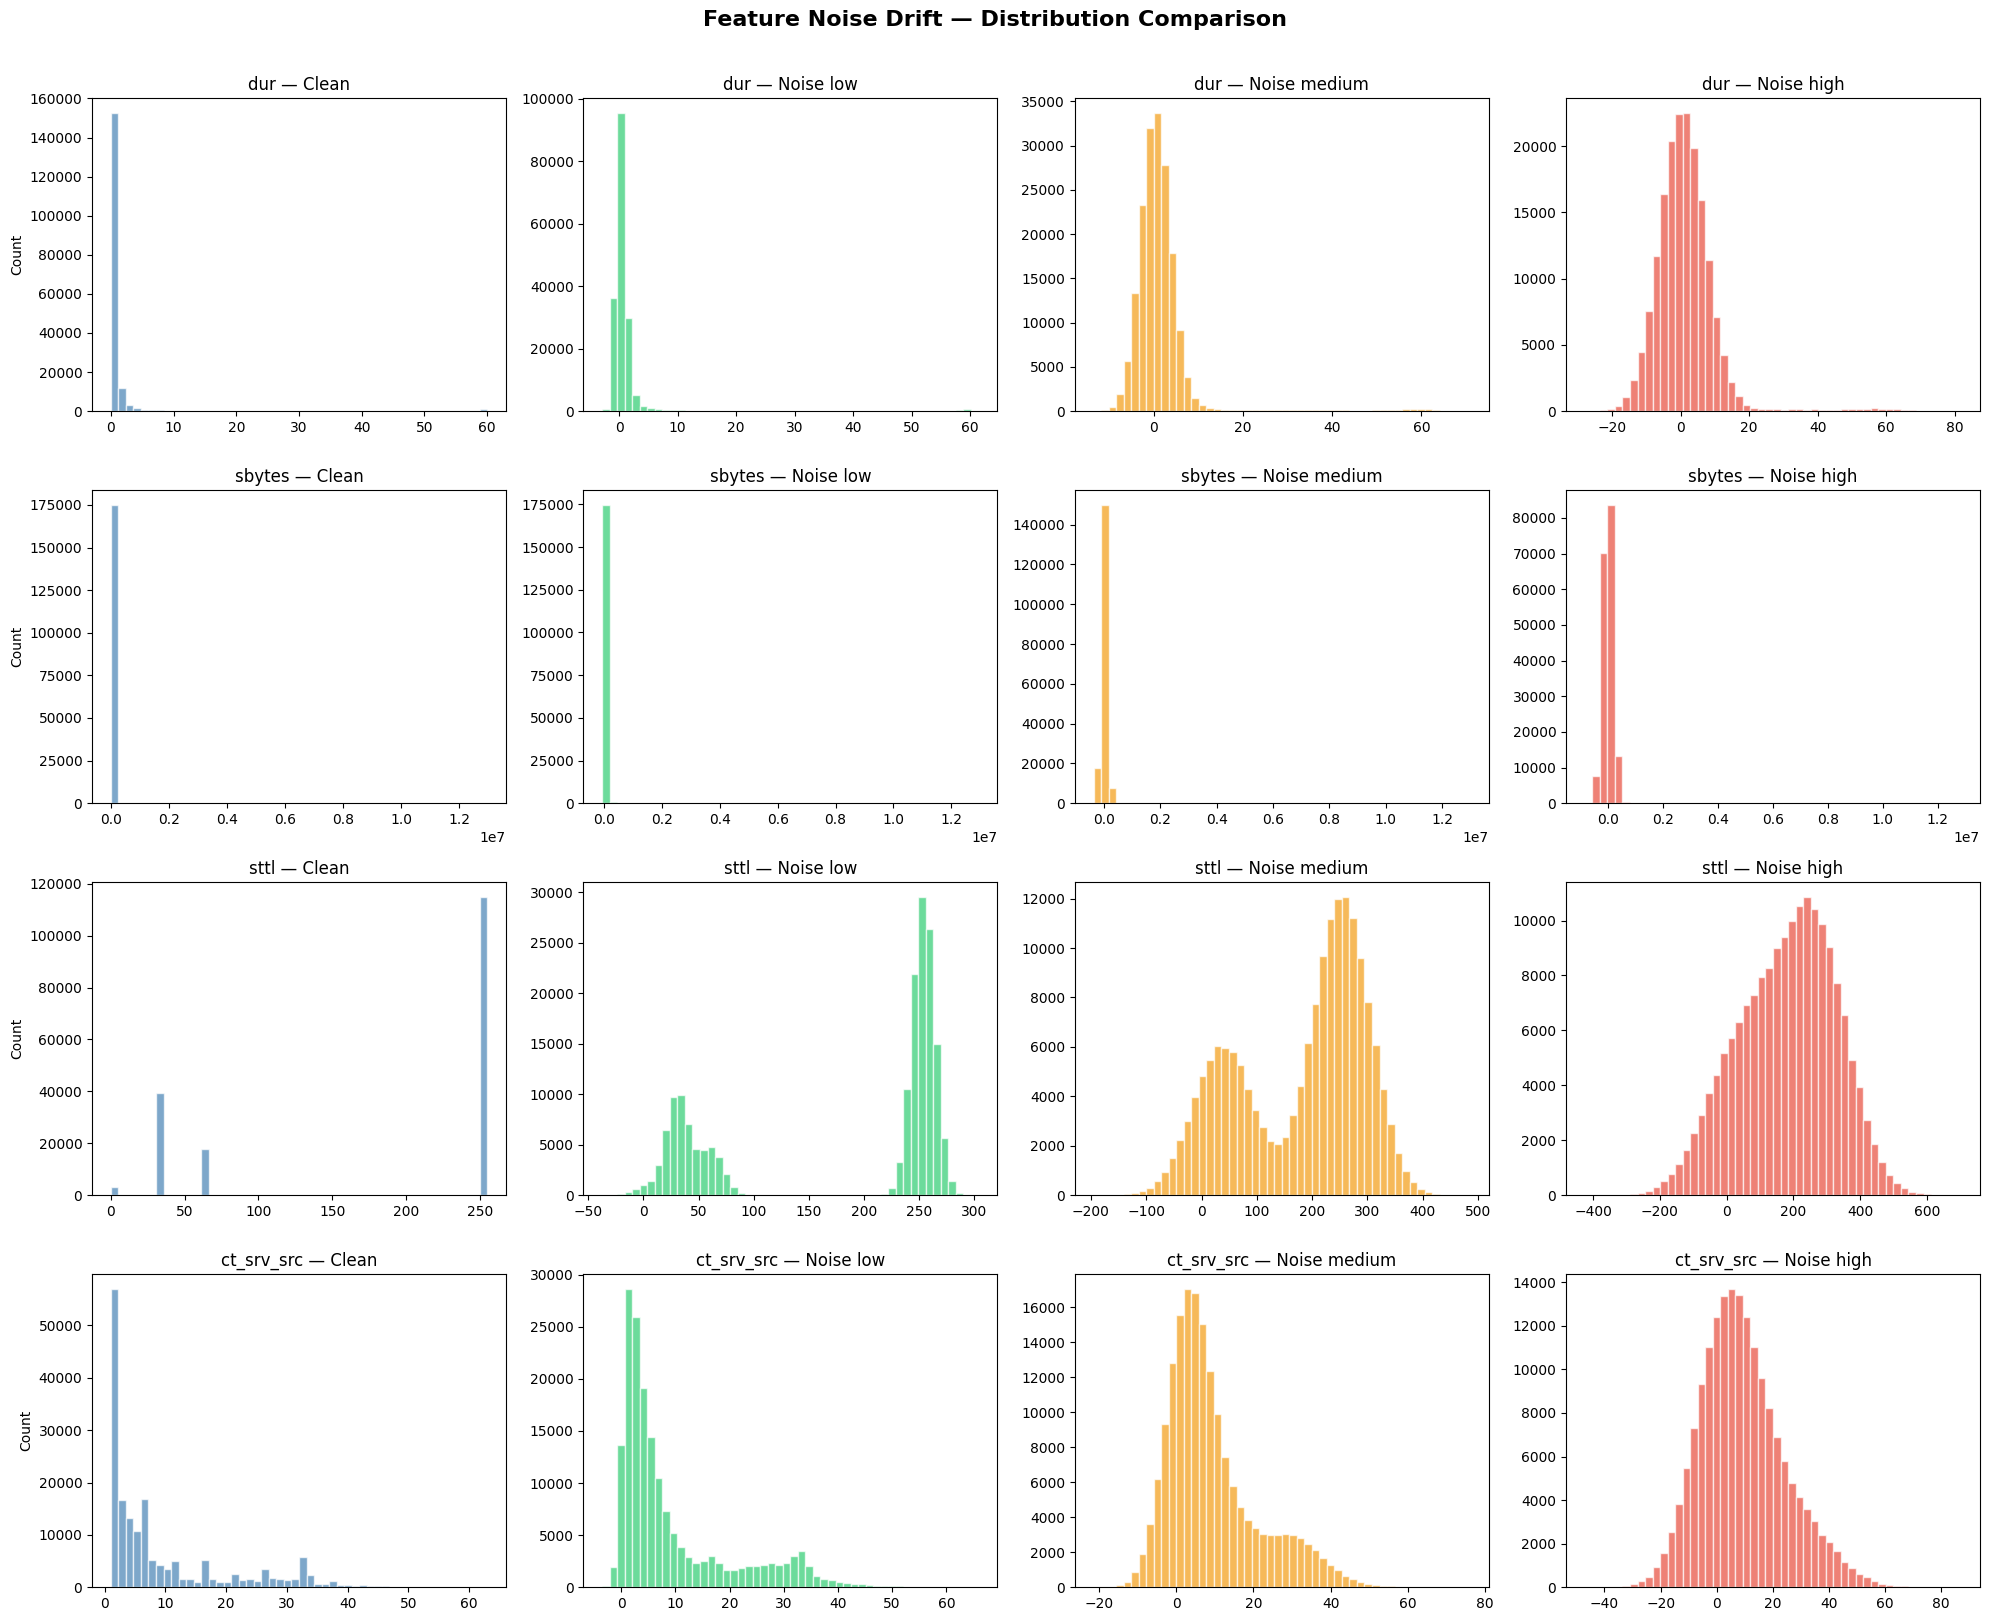

Saved: data/week3_fig_noise_distributions.png


In [14]:
# Select 4 representative features (diverse in nature)
plot_features = ['dur', 'sbytes', 'sttl', 'ct_srv_src']
plot_features = [f for f in plot_features if f in numeric_cols]
if len(plot_features) < 4:
    plot_features = numeric_cols[:4]

fig, axes = plt.subplots(len(plot_features), 4, figsize=(20, 4*len(plot_features)))
fig.suptitle('Feature Noise Drift — Distribution Comparison', fontsize=16, fontweight='bold', y=1.01)

for i, feat in enumerate(plot_features):
    axes[i, 0].hist(X_test_clean[feat], bins=50, alpha=0.7, color='steelblue', edgecolor='white')
    axes[i, 0].set_title(f'{feat} — Clean')
    axes[i, 0].set_ylabel('Count')
    
    colors = {'low': '#2ecc71', 'medium': '#f39c12', 'high': '#e74c3c'}
    for j, severity in enumerate(['low', 'medium', 'high']):
        axes[i, j+1].hist(noise_datasets[severity][feat], bins=50, alpha=0.7,
                          color=colors[severity], edgecolor='white')
        axes[i, j+1].set_title(f'{feat} — Noise {severity}')

plt.tight_layout()
plt.savefig('data/week3_fig_noise_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: data/week3_fig_noise_distributions.png')

---
### 9. Figure 2 — How Missingness Changes Feature Distributions

**What this figure shows:**  
Same layout as Figure 1, but for missingness drift instead of noise.

**What to look for:**
- A growing **spike at 0** as severity increases. This is the signature of missingness:
  values that should have been meaningful are replaced by 0.
- At **High** (50% masked): the spike at 0 dominates the histogram. Half the data is gone.
- Features that originally had few 0 values (like `sttl`, which is usually ~254) will show
  the spike most clearly, because a 0 in `sttl` is obviously anomalous.
- Features that naturally have many 0 values (like `dur` for very short connections) will
  show a less obvious spike, because the fake 0s blend in with real 0s.

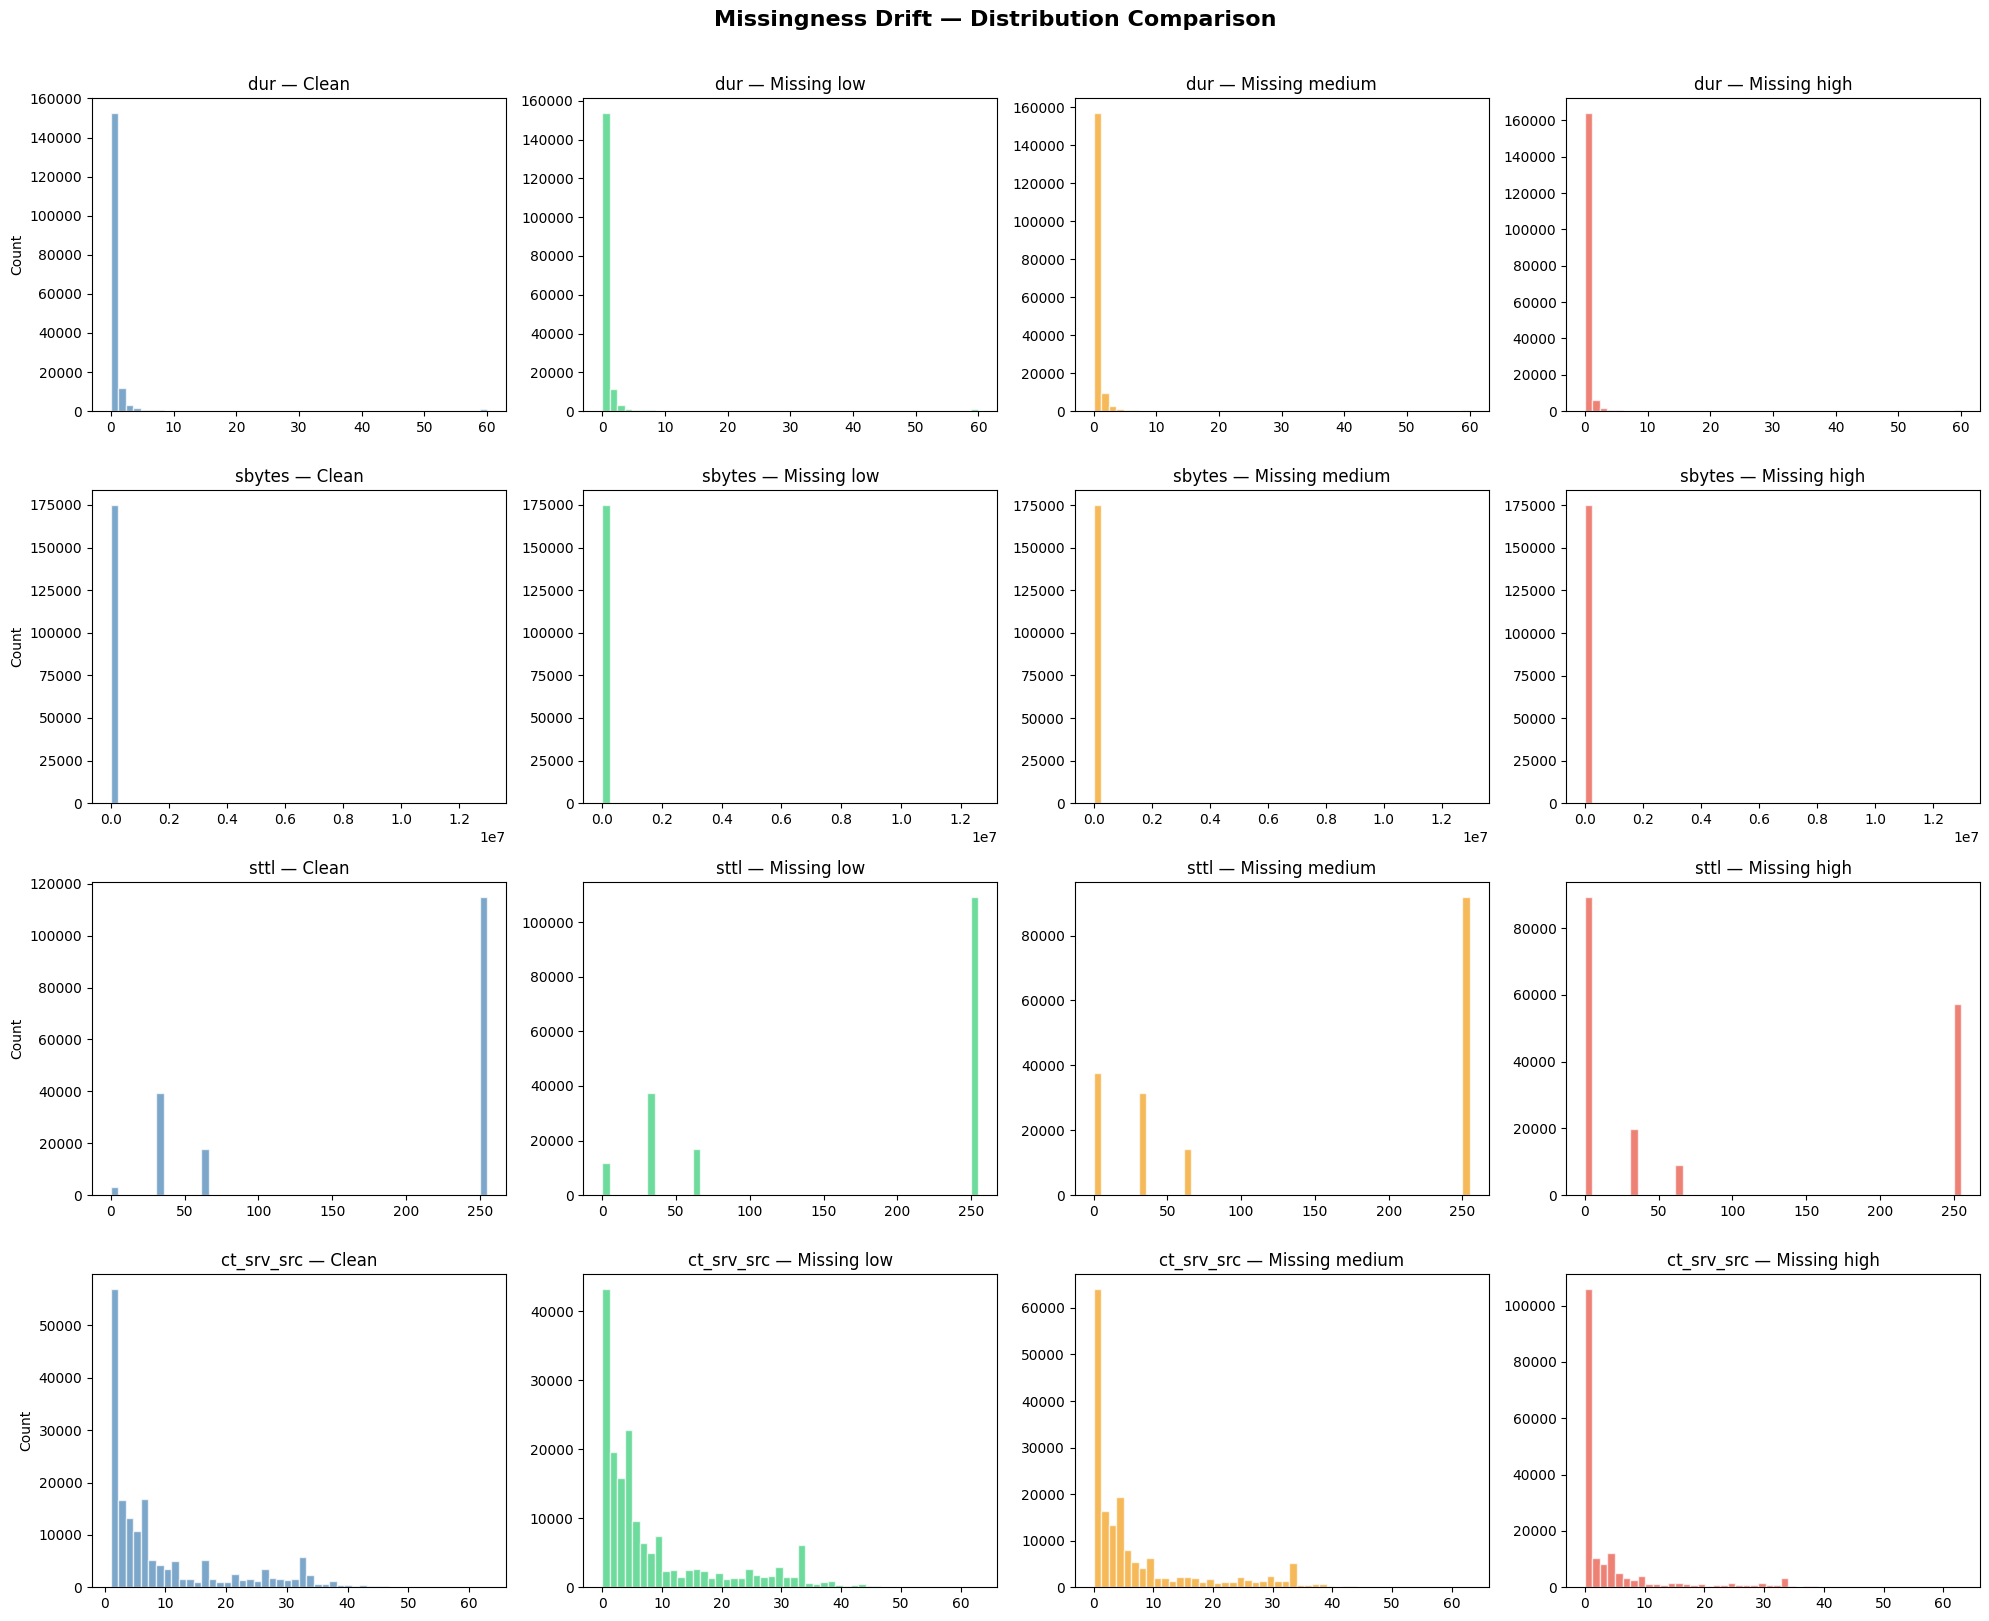

Saved: data/week3_fig_missingness_distributions.png


In [15]:
fig, axes = plt.subplots(len(plot_features), 4, figsize=(20, 4*len(plot_features)))
fig.suptitle('Missingness Drift — Distribution Comparison', fontsize=16, fontweight='bold', y=1.01)

for i, feat in enumerate(plot_features):
    axes[i, 0].hist(X_test_clean[feat], bins=50, alpha=0.7, color='steelblue', edgecolor='white')
    axes[i, 0].set_title(f'{feat} — Clean')
    axes[i, 0].set_ylabel('Count')
    
    colors = {'low': '#2ecc71', 'medium': '#f39c12', 'high': '#e74c3c'}
    for j, severity in enumerate(['low', 'medium', 'high']):
        axes[i, j+1].hist(miss_datasets[severity][feat], bins=50, alpha=0.7,
                          color=colors[severity], edgecolor='white')
        axes[i, j+1].set_title(f'{feat} — Missing {severity}')

plt.tight_layout()
plt.savefig('data/week3_fig_missingness_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: data/week3_fig_missingness_distributions.png')

---
### 10. Figure 3 — Recall Degradation for Random Forest

**What this figure shows:**  
A bar chart comparing Random Forest's Recall across all 9 drift scenarios.
The red dashed line is the clean baseline — any bar below this line means the model
is **missing more attacks** than it does on clean data.

**How to read it:**
- X-axis: severity level (Low → Medium → High)
- Y-axis: Recall = fraction of real attacks correctly detected
- 3 bar colors = 3 drift types
- The further a bar is below the red line, the worse the degradation

**What to look for:**
- Which drift type causes the **steepest drop**? That's the most dangerous one.
- Does any drift type barely affect Recall? That one is less of a safety concern.
- Does degradation scale linearly with severity, or is there a "cliff" where
  performance suddenly collapses?

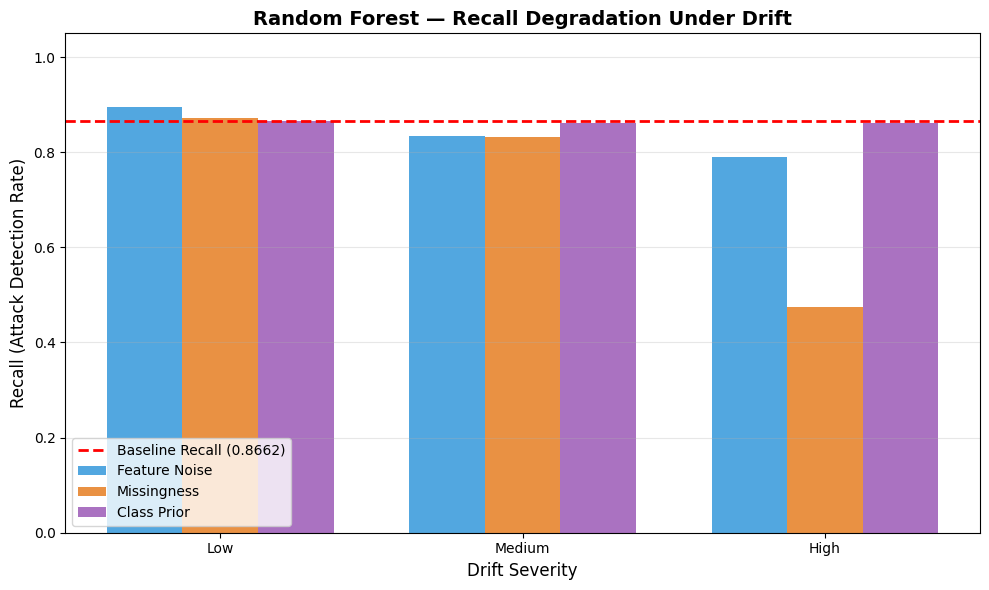

Saved: data/week3_fig_recall_degradation_rf.png


In [16]:
severities = ['low', 'medium', 'high']
rf_baseline_recall = baseline_results['Random Forest']['Recall']

noise_recalls = [noise_results[s]['Random Forest']['Recall'] for s in severities]
miss_recalls  = [miss_results[s]['Random Forest']['Recall'] for s in severities]
class_recalls = [class_results[s]['Random Forest']['Recall'] for s in severities]

fig, ax = plt.subplots(figsize=(10, 6))

x = np.arange(len(severities))
width = 0.25

ax.bar(x - width, noise_recalls, width, label='Feature Noise', color='#3498db', alpha=0.85)
ax.bar(x,         miss_recalls,  width, label='Missingness',   color='#e67e22', alpha=0.85)
ax.bar(x + width, class_recalls, width, label='Class Prior',   color='#9b59b6', alpha=0.85)

ax.axhline(y=rf_baseline_recall, color='red', linestyle='--', linewidth=2,
           label=f'Baseline Recall ({rf_baseline_recall:.4f})')

ax.set_xlabel('Drift Severity', fontsize=12)
ax.set_ylabel('Recall (Attack Detection Rate)', fontsize=12)
ax.set_title('Random Forest — Recall Degradation Under Drift', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(['Low', 'Medium', 'High'])
ax.legend(loc='lower left')
ax.set_ylim(0, 1.05)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('data/week3_fig_recall_degradation_rf.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: data/week3_fig_recall_degradation_rf.png')

---
### 11. Figure 4 — All Models Compared Under Drift

Same analysis as Figure 3, but for all 3 models side by side.
Shows which model is most robust to each drift type.

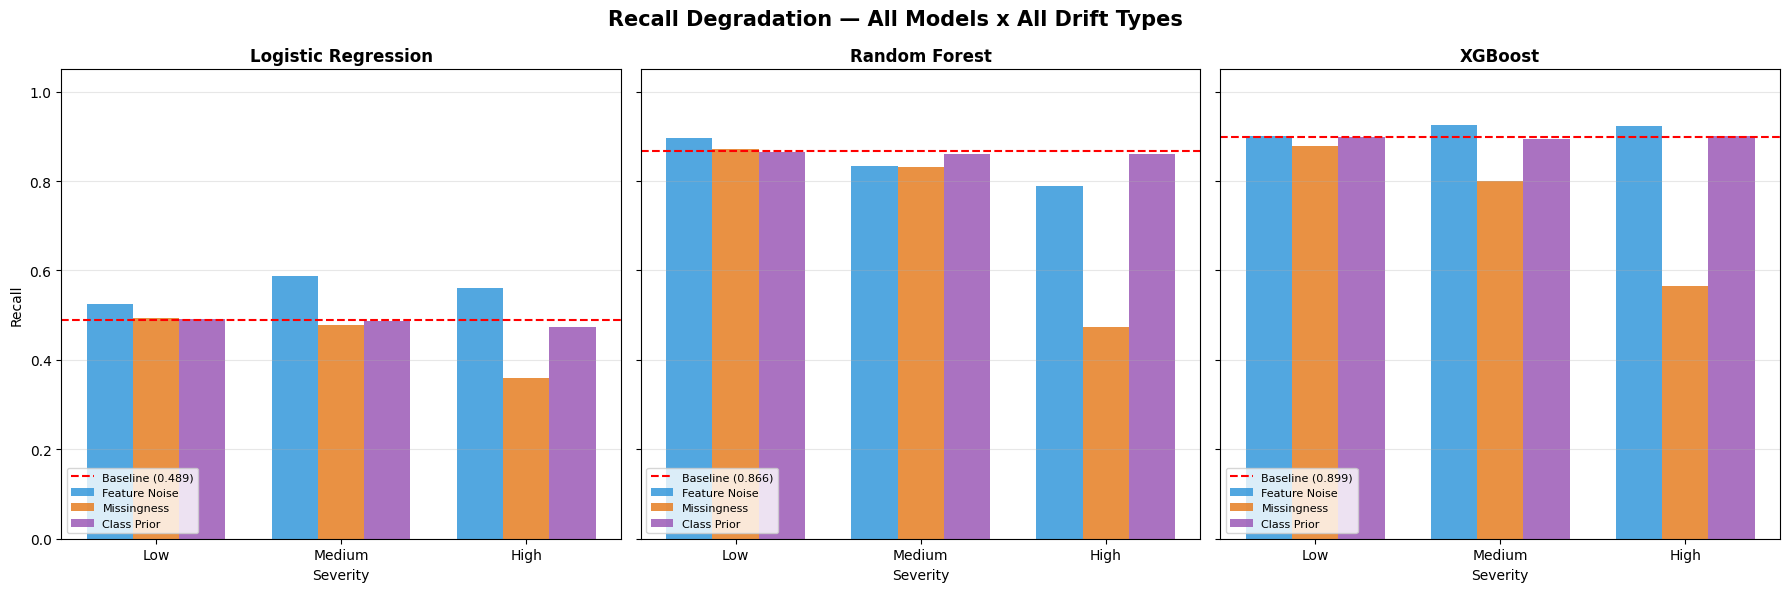

Saved: data/week3_fig_all_models_recall.png


In [17]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)
fig.suptitle('Recall Degradation — All Models x All Drift Types', fontsize=15, fontweight='bold')

drift_data = {
    'Feature Noise': noise_results,
    'Missingness': miss_results,
    'Class Prior': class_results
}
drift_colors = {'Feature Noise': '#3498db', 'Missingness': '#e67e22', 'Class Prior': '#9b59b6'}
model_names = ['Logistic Regression', 'Random Forest', 'XGBoost']

for ax_idx, model_name in enumerate(model_names):
    ax = axes[ax_idx]
    x = np.arange(3)
    width = 0.25
    
    for i, (drift_type, results_dict) in enumerate(drift_data.items()):
        recalls = [results_dict[s][model_name]['Recall'] for s in severities]
        ax.bar(x + (i-1)*width, recalls, width, label=drift_type,
               color=drift_colors[drift_type], alpha=0.85)
    
    baseline_r = baseline_results[model_name]['Recall']
    ax.axhline(y=baseline_r, color='red', linestyle='--', linewidth=1.5,
               label=f'Baseline ({baseline_r:.3f})')
    
    ax.set_title(model_name, fontsize=12, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(['Low', 'Medium', 'High'])
    ax.set_xlabel('Severity')
    ax.set_ylim(0, 1.05)
    ax.grid(axis='y', alpha=0.3)
    if ax_idx == 0:
        ax.set_ylabel('Recall')
    ax.legend(fontsize=8, loc='lower left')

plt.tight_layout()
plt.savefig('data/week3_fig_all_models_recall.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: data/week3_fig_all_models_recall.png')

---
### 12. Recall Drop Summary (Delta vs Baseline)

Shows the exact Recall loss (in points) for each scenario compared to clean performance.

In [18]:
print('='*70)
print('RECALL DROP (delta vs baseline)')
print('='*70)
print(f'{"Drift Type":<16} {"Severity":<10}', end='')
for m in model_names:
    print(f' {m:>22}', end='')
print()
print('-'*70)

all_drift_results = {
    'Feature Noise': noise_results,
    'Missingness': miss_results,
    'Class Prior': class_results
}

for drift_type, results_dict in all_drift_results.items():
    for severity in severities:
        print(f'{drift_type:<16} {severity:<10}', end='')
        for model_name in model_names:
            baseline_r = baseline_results[model_name]['Recall']
            drift_r = results_dict[severity][model_name]['Recall']
            delta = drift_r - baseline_r
            sign = '+' if delta >= 0 else ''
            print(f' {sign}{delta:>20.4f}', end='')
        print()
    print()

print('Negative = recall loss (more attacks missed)')
print('='*70)

RECALL DROP (delta vs baseline)
Drift Type       Severity      Logistic Regression          Random Forest                XGBoost
----------------------------------------------------------------------
Feature Noise    low        +              0.0356 +              0.0296 +              0.0011
Feature Noise    medium     +              0.0990              -0.0331 +              0.0253
Feature Noise    high       +              0.0720              -0.0767 +              0.0241

Missingness      low        +              0.0056 +              0.0062              -0.0197
Missingness      medium                  -0.0099              -0.0347              -0.0993
Missingness      high                    -0.1293              -0.3915              -0.3335

Class Prior      low        +              0.0025              -0.0002 +              0.0002
Class Prior      medium                  -0.0008              -0.0045              -0.0042
Class Prior      high                    -0.0150           

---
### 13. Save Drifted Datasets & Summary

All 9 drifted test sets are saved for reuse in Week 4 (deeper analysis)
and Week 5 (drift detection with PSI, KS, SafeML).

In [ ]:
import os
os.makedirs('data/drifted', exist_ok=True)

for severity in severities:
    noise_datasets[severity].to_csv(f'data/drifted/noise_{severity}.csv', index=False)
    miss_datasets[severity].to_csv(f'data/drifted/miss_{severity}.csv', index=False)
    X_cls, y_cls = class_datasets[severity]
    cls_df = X_cls.copy()
    cls_df['label'] = y_cls
    cls_df.to_csv(f'data/drifted/class_prior_{severity}.csv', index=False)

print('Drifted datasets saved to data/drifted/')
print()
print()
print('  Deliverables produced:')
print('  - 9 drifted test sets (3 types x 3 severities)')
print('  - Table 3: all drift results (week3_all_drift_results.csv)')
print('  - Scenario definitions table (week3_scenario_definitions.csv)')
print('  - Distribution comparison figures (noise + missingness)')
print('  - Recall degradation plots (RF + all models)')
print('  - Recall drop summary table')


Drifted datasets saved to data/drifted/

  WEEK 3 COMPLETE

  Deliverables produced:
  - 9 drifted test sets (3 types x 3 severities)
  - Table 3: all drift results (week3_all_drift_results.csv)
  - Scenario definitions table (week3_scenario_definitions.csv)
  - Distribution comparison figures (noise + missingness)
  - Recall degradation plots (RF + all models)
  - Recall drop summary table
